In [ ]:
%load_ext autoreload
%autoreload 2

from spatial_tcr.utils import setup_plotting, switch_cwd_to_root

switch_cwd_to_root()

import os

figure_dir = "figures/revision/supplement"
setup_plotting(figure_dir, display_dpi=300, save_dpi=300)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from tqdm.auto import tqdm

from spatial_tcr.clonal_expansion import (
    calc_empirical_p_values,
    filter_clonal_clusters_by_cell_type,
    identify_clonal_clusters,
    merge_clonal_clusters,
    remove_minority_avbv_expression,
)
from spatial_tcr.permutation import permute_positions
from spatial_tcr.tcr import get_tcr_genes

In [9]:
data_dir = "data/xenium/processed"
path = f"{data_dir}/07.1-kidney_tcr_clones.h5ad"
adata = sc.read_h5ad(path)
adata

AnnData object with n_obs × n_vars = 510139 × 431
    obs: 'sample', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'condition', 'cc', 'cell_type_no_tcr', 'cell_type_no_tcr_prob', 'tcell_subtype', 'cell_type_l1', 'cell_type_l2', 'is_ATL', 'is_B', 'is_CNT', 'is_DCT', 'is_DTL', 'is_EC', 'is_FIB', 'is_IC', 'is_MAST', 'is_MC', 'is_MDC', 'is_Mac', 'is_N', 'is_NEU', 'is_PC', 'is_PEC', 'is_PL', 'is_POD', 'is_PT', 'is_PapE', 'is_T', 'is_TAL', 'is_VSM/P', 'is_cDC', 'is_cycMNP', 'is_glom. EC', 'is_pDC', 'is_unknown', 'leiden', 'glom_annot', 'in_glom', 'tcell_density_group', 'tcell_density', 'tcell_infiltrate', 'cell_type_l1.1', 'av_

In [10]:
av_genes, bv_genes = get_tcr_genes(adata)[0:2]

Found 35 TRAV genes, 31 TRBV genes, 3 TRDV genes, 14 TRGV genes


In [11]:
# optionally remove minorty avbv expression per cell
remove_minority_avbv_expression(
    adata, av_genes, bv_genes, out_layer="avbv_clean", in_layer="counts"
)

Sum of X_in before removal: 39286823.0
Sum of X_in after removal: 39283135.0


In [12]:
adata.X = adata.layers["avbv_clean"].copy()
# adata.X = adata.layers["counts"].copy()
# Get unique elements per row by iterating through each row
max_nunique_per_row_av = max(
    [len(np.unique(row)) for row in adata[:, av_genes].X.toarray()]
)
max_nunique_per_row_bv = max(
    [len(np.unique(row)) for row in adata[:, bv_genes].X.toarray()]
)
print(f"Max number of unique AV genes per cell: {max_nunique_per_row_av}")
print(f"Max number of unique BV genes per cell: {max_nunique_per_row_bv}")

Max number of unique AV genes per cell: 2
Max number of unique BV genes per cell: 2


In [13]:
np.unique(adata[:, av_genes].X.toarray(), axis=1).shape

(510139, 35)

In [14]:
ad_t = adata[adata.obs["cell_type_l1"] == "T"].copy()
ad_t.obs["cell_type_l2"].value_counts().sum()

np.int64(20033)

In [15]:
ad_t.obs["cell_type_l1.1"].value_counts().sum()

np.int64(20033)

In [16]:
ct_key = "cell_type_l2"
tcell_keys = [
    "CD4+",
    "Tregs",
    "MAIT",
    "CD8+",
    "NKT-like",
]


ct_key = "cell_type_l1.1"
tcell_keys = [
    "CD4+",
    "MAIT",
    "CD8+",
    "NKT-like",
]


clone_df = identify_clonal_clusters(
    adata,
    ct_key=ct_key,
    av_genes=av_genes,
    bv_genes=bv_genes,
    sample_key="cc",
    tcell_keys=tcell_keys,
    max_dist=100,
    min_cells=2,
    layer="avbv_clean",
)

Considering 19587 cells for clonal expansion analysis
Found 4294 cells expressing at least one AV and BV gene
Found 929 distinct AVBV combinations
Found 255 clonal clusters
Found 559 cells in clonal clusters


In [17]:
avbv_cluster = merge_clonal_clusters(clone_df)
adata.obs["avbv_cluster"] = None
adata.obs.loc[avbv_cluster.index, "avbv_cluster"] = avbv_cluster

Total number of clonal clusters after merging: 196


In [18]:
filter_clonal_clusters_by_cell_type(
    adata,
    ct_key="cell_type_l1.1",
    prohibited_combinations=[("CD4+", "CD8+")],
    in_key="avbv_cluster",
    out_key="avbv_cluster_filtered",
    verbose=1,
)

Filtering:   0%|          | 0/196 [00:00<?, ?it/s]

Total number of clonal clusters after filtering: 145


/tmp/ipykernel_1234781/2193017698.py:8: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_sub, color=cc_key, show=True, spot_size=20)


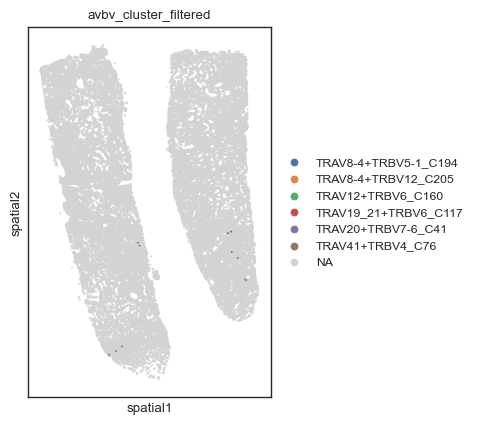

In [19]:
cc_key = "avbv_cluster_filtered"
# cc_key = "avbv_cluster"

for sample in adata.obs["sample"].unique()[1:2]:
    ad_sub = adata[adata.obs["sample"] == sample].copy()
    if ad_sub.obs[cc_key].notna().sum() == 0:
        continue
    sc.pl.spatial(ad_sub, color=cc_key, show=True, spot_size=20)

In [20]:
adata.X = adata.layers["counts"].copy()

In [ ]:
adata.write_h5ad(f"{data_dir}/08.1-kidney_tcr_clonal_clusters.h5ad")

/home/dschaub/.uv-local/venvs/xenium-tcr/lib/python3.13/site-packages/anndata/_io/utils.py:243: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)


## Random permutation test

permute full expression per cell

In [ ]:
seed = 42
rng = np.random.RandomState(seed)
n_perms = 1000
layer = "avbv_clean"
# layer = "counts"
save_path = f"results/revision/clonal-expansion/clonal_clusters_simulated_postionwise_{layer}.csv"

if not os.path.exists(save_path):
    ad_tmp = adata[adata.obs[ct_key].isin(tcell_keys), av_genes + bv_genes].copy()

    cluster_results = []

    for _ in tqdm(range(n_perms)):
        ad_perm = ad_tmp.copy()

        ad_perm = permute_positions(ad_perm, rng=rng, sample_key="cc")

        # randomly scatter gene expression around t cells
        # ad_perm = permute_gene_expression(ad_perm, rng=rng, sample_key="cc")

        clone_df = identify_clonal_clusters(
            ad_perm,
            av_genes=av_genes,
            bv_genes=bv_genes,
            sample_key="cc",
            max_dist=100,
            min_cells=2,
            verbose=False,
            layer=layer,
        )
        avbv_cluster = merge_clonal_clusters(clone_df, verbose=False)
        ad_perm.obs["avbv_cluster"] = None
        ad_perm.obs.loc[avbv_cluster.index, "avbv_cluster"] = avbv_cluster
        filter_clonal_clusters_by_cell_type(
            ad_perm,
            ct_key="cell_type_l1.1",
            prohibited_combinations=[("CD4+", "CD8+")],
            in_key="avbv_cluster",
            out_key="avbv_cluster_filtered",
            prog_bar=False,
        )
        cluster_results.append(ad_perm.obs["avbv_cluster_filtered"])

    cluster_results = pd.concat(cluster_results, axis=1)
    cluster_results.to_csv(save_path)

In [21]:
layer = "avbv_clean"
save_path = f"results/revision/clonal-expansion/clonal_clusters_simulated_postionwise_{layer}.csv"
cluster_results = pd.read_csv(save_path, index_col=0)
# cluster_results.nunique().values

/tmp/ipykernel_1234781/3633255108.py:3: DtypeWarning: Columns (1,5,7,17,21,22,26,29,33,34,40,43,53,58,62,69,70,71,72,73,76,86,87,89,91,92,94,95,98,100,114,117,118,126,135,137,140,143,145,146,148,156,163,164,171,176,179,182,184,185,195,206,207,210,211,213,214,217,223,230,233,235,248,255,260,263,268,274,277,280,281,289,295,297,298,304,305,306,310,319,320,321,322,324,326,329,330,347,348,358,361,363,364,365,377,384,388,391,393,398,400,403,404,405,407,411,412,413,417,422,424,429,438,442,444,448,455,460,471,472,473,474,475,478,481,482,487,490,491,493,498,499,500,505,515,518,520,525,527,539,541,542,544,545,547,552,555,556,557,571,573,582,586,587,598,600,604,605,608,610,612,620,621,627,630,635,638,640,644,652,654,656,661,664,672,674,678,682,683,686,688,691,694,695,711,712,714,718,720,722,724,727,728,730,738,739,743,744,747,748,749,750,754,758,759,762,763,765,774,775,776,783,787,790,794,806,807,811,816,818,820,826,827,829,831,836,842,846,850,851,853,855,857,858,861,864,867,871,874,884,893,896,8

In [22]:
n_perms = 1000
counts_sim = cluster_results.nunique().values
counts_obs = adata.obs["avbv_cluster_filtered"].nunique()
z_scores, p_values, q_values = calc_empirical_p_values(counts_obs, counts_sim, n_perms)
print(p_values)
print(q_values)

p_values_high: 0.000999000999000999
p_values_low: 1.0
0.000999000999000999
[0.000999]


[np.float64(78.1875), np.float64(80.5625), np.float64(82.9375), np.float64(85.3125), np.float64(87.6875), np.float64(90.0625), np.float64(92.4375), np.float64(94.8125), np.float64(97.1875), np.float64(99.5625), np.float64(101.9375), np.float64(104.3125), np.float64(106.6875), np.float64(109.0625), np.float64(111.4375), np.float64(113.8125), np.float64(116.1875), np.float64(118.5625), np.float64(120.9375), np.float64(123.3125), np.float64(125.6875), np.float64(128.0625), np.float64(130.4375), np.float64(132.8125)]


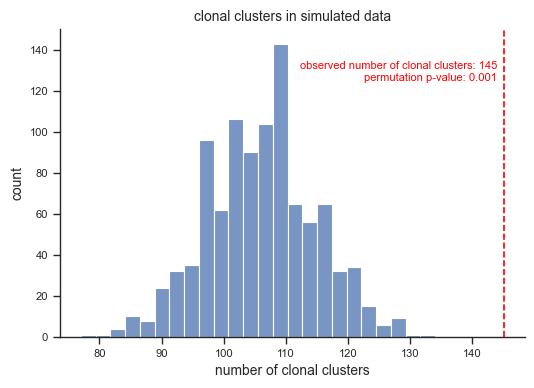

In [23]:
sns.set_theme(style="ticks", context="paper")
fig, ax = plt.subplots(figsize=(6, 4))
hist = sns.histplot(counts_sim, ax=ax)
ax.set_xlabel("number of clonal clusters", fontsize=10)
ax.set_ylabel("count", fontsize=10)
ax.set_title("clonal clusters in simulated data", fontsize=10)
ax.tick_params(axis="both", labelsize=8)

# Get the bar coordinates
# for p in hist.patches:
#     print(f"Bar center: {p.get_x() + p.get_width() / 2:.2f}, height: {p.get_height()}")

bar_centers = [p.get_x() + p.get_width() / 2 for p in hist.patches]
print(bar_centers)

# draw red vertical line for observed number of clonal clusters
ax.axvline(counts_obs, color="red", linestyle="--")
# add text for observed number of clonal clusters
ax.text(
    counts_obs - 1,
    125,
    f"observed number of clonal clusters: {counts_obs}\npermutation p-value: {np.round(p_values, 5)}",
    color="red",
    ha="right",
    fontsize=8,
)

# split x axis into two parts
sns.despine(ax=ax)

plt.savefig(
    os.path.join(figure_dir, "clonal_clusters_simulated_postionwise_avbv_clean.pdf"),
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)
# plt.close()